# Where should you throw, if the point is to be measured?

Notebook 07 fitted a player's throwing distribution from the scores they wrote down. It
answered: *given that these darts were aimed at one spot, how tight was the group?*

Two choices were buried in that question and never examined.

1. **Which spot?** The fit takes the target as given. But some targets tell you far more
   about a player than others, and nothing so far has said which.
2. **Why one spot?** A session is a fixed budget of darts. Nothing says they all have to go
   at the same target. Perhaps 100 darts at each of two targets measures a player better
   than 200 at one.

Both are questions of **experimental design**, and both have exact answers. This notebook
computes them, *proves* the second one optimal rather than merely searching for it, and
then checks the whole thing against simulated sessions at realistic lengths -- where the
answer turns out to be considerably more interesting than the theory suggests.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts import players
from darts.dartboards import generate_dartboard
from darts.design import (best_pair, best_single_target, c_criterion,
                          candidate_targets, design_information,
                          equivalence_certificate, greedy_design,
                          information_at_points, information_maps,
                          optimal_design, sigma_gradient)
from darts.utils import aim_description, mm_per_pixel

PX = 512
STRIDE = 4
BOARD, _ = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
N_REF = 200          # darts in a reference session

def polar(r, deg):
    '''Pixel coordinates r mm from the centre, deg clockwise from the 20.'''
    return (int(round(CENTRE + r * np.cos(np.deg2rad(deg)) / MM)),
            int(round(CENTRE + r * np.sin(np.deg2rad(deg)) / MM)))

RESULTS = os.path.join(module_path, 'results')

### Where the numbers come from, and how to rebuild them

Some of this notebook computes live (the information maps, the design searches, the
verification appendix); the rest reads results that take minutes to hours and are committed
under `results/` so the notebook re-runs without re-solving anything.

| script | writes | roughly |
|---|---|---|
| `scripts/optimal_measurement_design.py` | `results/manifest_design.csv`, `results/design/design_{band}.npz` | 5 min, mostly the exhaustive pair search |
| `scripts/best_target_by_sigma.py` | `results/manifest_best_target.csv` | 6 min for the whole sigma grid |
| `scripts/robust_measurement_design.py` | `results/manifest_design_robust.csv`, `manifest_design_cross.csv`, `design/robust.npz` | 1 min |
| `scripts/design_simulation_study.py` | `results/design/simulation_league.csv` | ~4 h for four session lengths x eight designs x 250 replicates |
| `scripts/why_splitting_helps.py` | `results/design/why_splitting.csv` | 20 min |
| `scripts/two_stage_design.py` | `results/design/two_stage.csv` | 1 h 20 for three bands |

Run them in that order -- the two-stage study needs the lookup table and the robust design,
and the simulation study needs the per-band designs.

The equivalent checks as assertions, rather than as tables to read, are in
`tests/test_design.py`.

## The model of a measurement session

The player is asked to aim at targets $t_1 \dots t_k$ and throws $n_i$ darts at each. A
dart aimed at $t_i$ lands at

$$Z \sim N(t_i + b,\ \Sigma)$$

where $b$ is a systematic bias -- the player pulls low and left, say -- and $\Sigma$ is the
spread we want. Only the **score** is recorded, never the position. So the parameters are

$$\theta = (b_x,\ b_y,\ \Sigma_{xx},\ \Sigma_{xy},\ \Sigma_{yy})$$

Five numbers, **whatever $k$ is**. That is what makes the comparison fair: "200 darts at
one target" and "100 at each of two" both estimate exactly five parameters, so any
difference between them is information and not degrees of freedom. `fit_multi_target`
implements this by exact EM, and reduces to notebook 07's single-target fit when $k = 1$.

## How much a target tells you

The score at a given target is multinomial over the board's 44 possible values, so one
dart aimed at $t$ carries Fisher information

$$I(t) = \sum_s \frac{1}{p_s(t)}\, \nabla_\theta p_s(t)\, \nabla_\theta p_s(t)^{\!\top}$$

and the asymptotic standard error of $\hat\sigma$ from $n$ darts is
$\sqrt{c^\top M^{-1} c / n}$ with $c = \partial \sigma / \partial \theta$. Treating $b$ as a
nuisance parameter via $M^{-1}$, rather than just $1/I_{\sigma\sigma}$, correctly charges the
design for having to estimate where the player was actually aiming.

The derivatives $\nabla_\theta p_s$ are available in closed form, and because $p_s(t)$ is a
cross-correlation of the score mask with the throw kernel, **one FFT per score gives the
information at every target on the board at once** -- the same trick the transition builder
uses. The whole map costs about a second.

### First, are the derivatives right?

Everything below rests on $\nabla_\theta p_s(t)$, and an error there would produce
designs that looked perfectly plausible and were simply wrong. So before using them:
differentiate the score probabilities a completely different way -- finite differences of
`ScoreLikelihood`, which evaluates the Gaussian directly on the pixel grid and shares no
code with the FFT path -- and demand agreement.

This check earned its keep. It caught a sign error: the FFT helper convolves rather than
correlates, so it evaluates the board at $t - v$ and the effective mean is $t - b$. The
kernel is symmetric, so the mistake was invisible in the probabilities themselves *and* in
the even-order $\Sigma$ derivatives -- only the odd-order bias terms were wrong, which is
exactly the pattern the table below would have shown.

In [2]:
from darts.design import kernel_derivatives
from darts.fitting import ScoreLikelihood
from darts.transitions import _correlate_fft

PX_V = 128
board_v, _ = generate_dartboard(PX_V)
like_v = ScoreLikelihood(board=board_v)
Sigma_v = np.array([[16.0 ** 2, 40.0], [40.0, 13.0 ** 2]])   # deliberately tilted
mm_v = mm_per_pixel(PX_V)
allowed_v = np.unique(board_v).astype(int)
target_v = (PX_V // 2 - 20, PX_V // 2 + 12)

def p_direct(b, S):
    mu = np.array([(target_v[1] - PX_V // 2) * mm_v + b[0],
                   (target_v[0] - PX_V // 2) * mm_v + b[1]])
    pr = like_v.score_probabilities(mu, S)
    return np.array([pr[int(s)] for s in allowed_v])

numeric, h = [], 1e-4
for k in range(2):                       # d/db
    e = np.zeros(2); e[k] = h
    numeric.append((p_direct(e, Sigma_v) - p_direct(-e, Sigma_v)) / (2 * h))
for a, b in [(0, 0), (0, 1), (1, 1)]:    # d/dSigma
    E = np.zeros((2, 2)); E[a, b] = E[b, a] = 1.0
    hh = 1e-4 * Sigma_v[0, 0]
    numeric.append((p_direct(np.zeros(2), Sigma_v + hh * E)
                    - p_direct(np.zeros(2), Sigma_v - hh * E)) / (2 * hh))

_, dK = kernel_derivatives(PX_V, Sigma_v, mm_v)
masks = np.stack([(board_v == s).astype(float) for s in allowed_v])
analytic = np.stack([_correlate_fft(masks, d)[:, target_v[0], target_v[1]] for d in dK])

pd.DataFrame([{'parameter': n,
               'max |analytic - numeric|': np.abs(analytic[i] - numeric[i]).max(),
               'scale of the derivative': np.abs(numeric[i]).max(),
               'sum_s dp_s (must be 0)': analytic[i].sum()}
              for i, n in enumerate(['b_x', 'b_y', 'S_xx', 'S_xy', 'S_yy'])]
            ).set_index('parameter')

,max |analytic - numeric|,scale of the derivative,sum_s dp_s (must be 0)
parameter,,,
b_x,5.511633e-13,0.016337,2.926922e-18
b_y,2.020571e-13,0.008669,2.913158e-18
S_xx,1.470633e-12,0.000476,-2.284077e-19
S_xy,1.995034e-12,0.000437,2.768739e-19
S_yy,2.373191e-12,0.000360,-9.558105e-19


,target,label,SE of sigma (mm),relative
0,bull,BULL,0.908,6%
1,T20,T20,1.357,8%
2,D20,D20,1.226,8%
3,20 (outer single),20,0.774,5%
4,T19,T10,1.466,9%


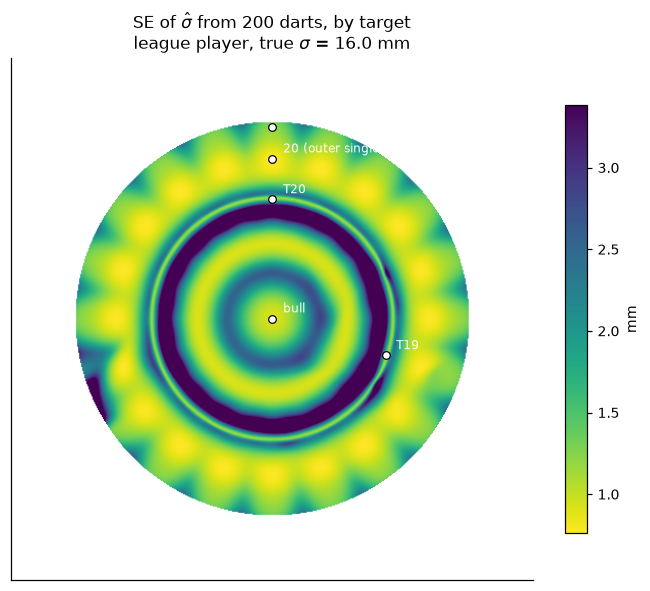

In [3]:
SIGMA = players.ABILITY_BANDS['league']
maps = information_maps(PX, SIGMA, board=BOARD)
c_vec = sigma_gradient(SIGMA)

# standard error of sigma-hat from N_REF darts, at every target on the board
se = np.full((PX, PX), np.nan)
rad = np.hypot(*np.meshgrid(np.arange(PX) - CENTRE, np.arange(PX) - CENTRE, indexing='ij'))
inside = rad <= 170 / MM
se[inside] = np.sqrt(c_criterion(maps['info'][inside], c_vec) / N_REF)

named = {'bull': polar(0, 0), 'T20': polar(103, 0), 'D20': polar(166, 0),
         '20 (outer single)': polar(138, 0), 'T19': polar(103, 108)}

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(se, origin='lower', cmap='viridis_r', vmax=np.nanpercentile(se, 92))
for name, p in named.items():
    ax.plot(p[1], p[0], 'o', ms=5, color='white', mec='black', mew=0.8)
    ax.annotate(name, (p[1], p[0]), textcoords='offset points', xytext=(7, 4),
                color='white', fontsize=8)
ax.set_title(f'SE of $\\hat\\sigma$ from {N_REF} darts, by target\n'
             f'league player, true $\\sigma$ = {SIGMA} mm')
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='mm')
fig.tight_layout()

pd.DataFrame([{'target': n, 'label': aim_description(p, PX),
               'SE of sigma (mm)': round(float(se[p[0], p[1]]), 3),
               'relative': f"{100*se[p[0], p[1]]/SIGMA:.0f}%"}
              for n, p in named.items()])

The map is not subtle. Darker is better, and the good region is a **ring out in the big
single area**, not any of the places a player would naturally throw.

The treble ring is among the *worst* places on the board to be measured, which is worth
sitting with, because T20 is exactly where a player practising would put 200 darts. The
treble bed is 8mm deep and this player's scatter is 16mm: they miss it nearly every time,
and the score they get instead -- 20, 5, 1 -- says little about *how far* they missed. The
information is in the **boundaries you cross**, and up at the treble the only nearby
boundaries are the segment edges, which measure the sideways scatter and say almost nothing
about the radial.

7305 candidate targets
best single target : 9  at r = 136 mm
  SE = 0.765 mm    vs T20: 1.357 mm
  choosing T20 instead costs a factor of 3.1 in variance


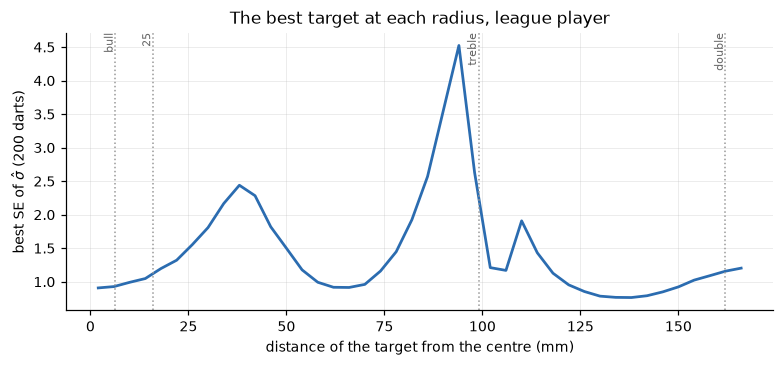

In [4]:
cand = candidate_targets(PX, point_stride=STRIDE)
I_pts = information_at_points(maps, cand)
i1, v1, allvals = best_single_target(I_pts, c_vec)
se_t20 = se[named['T20'][0], named['T20'][1]]
print(f'{len(cand)} candidate targets')
print(f'best single target : {aim_description(cand[i1], PX)}  '
      f'at r = {np.hypot(cand[i1][0]-CENTRE, cand[i1][1]-CENTRE)*MM:.0f} mm')
print(f'  SE = {np.sqrt(v1/N_REF):.3f} mm    vs T20: {se_t20:.3f} mm')
print(f'  choosing T20 instead costs a factor of '
      f'{(se_t20**2)/(v1/N_REF):.1f} in variance')

# the best target at each radius, taking the best angle
r_mm = np.hypot(cand[:, 0] - CENTRE, cand[:, 1] - CENTRE) * MM
bins = np.arange(0, 172, 4)
which = np.digitize(r_mm, bins) - 1
best_at_r = [np.sqrt(allvals[which == b].min() / N_REF) if (which == b).any() else np.nan
             for b in range(len(bins) - 1)]

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(bins[:-1] + 2, best_at_r, color='#2b6cb0', lw=1.8)
for r, lab in [(6.35, 'bull'), (15.9, '25'), (99, 'treble'), (162, 'double')]:
    ax.axvline(r, color='#999', ls=':', lw=1)
    ax.annotate(lab, (r, ax.get_ylim()[1]), rotation=90, fontsize=7,
                va='top', ha='right', color='#666')
ax.set_xlabel('distance of the target from the centre (mm)')
ax.set_ylabel(f'best SE of $\\hat\\sigma$ ({N_REF} darts)')
ax.set_title('The best target at each radius, league player')
fig.tight_layout()

## The answer changes completely with ability

Fisher information depends on the true parameters, so the best target depends on the
$\sigma$ being measured. It does not drift gently -- it jumps.

In [5]:
design = pd.read_csv(os.path.join(RESULTS, 'manifest_design.csv'))
tbl = design[['band', 'sigma_mm', 'se_bull', 'se_T20', 'se_D20', 'se_best1',
              'best1', 'best1_r_mm', 'se_optimal']].copy()
tbl.columns = ['band', 'sigma', 'bull', 'T20', 'D20', 'best single',
               'best target', 'its radius (mm)', 'best possible']
tbl.round(3)

,band,sigma,bull,T20,D20,best single,best target,its radius (mm),best possible
0,elite,6.5,0.272,0.636,1.920,0.272,BULL,0.000,0.272
1,pro,8.0,0.329,0.666,0.935,0.329,BULL,0.000,0.329
2,county,10.0,0.432,0.839,0.797,0.432,BULL,0.000,0.432
3,super_league,13.0,0.640,1.201,0.971,0.640,BULL,0.000,0.614
4,league,16.0,0.908,1.357,1.226,0.765,9,136.007,0.732
5,club,20.0,1.356,1.244,1.509,1.012,9,136.007,0.939
6,pub,28.0,2.355,1.265,2.023,1.244,T5,105.996,1.222


,band,sigma_mm,best1,variance_wasted_at_T20
0,elite,6.5,BULL,5.45
1,pro,8.0,BULL,4.09
2,county,10.0,BULL,3.78
3,super_league,13.0,BULL,3.52
4,league,16.0,9,3.14
5,club,20.0,9,1.51
6,pub,28.0,T5,1.04


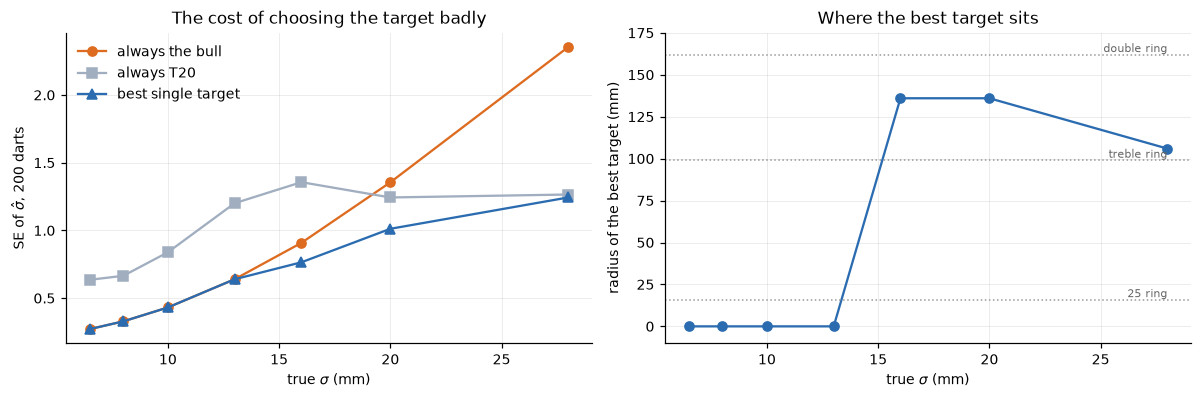

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
axes[0].plot(design.sigma_mm, design.se_bull, 'o-', label='always the bull', color='#dd6b20')
axes[0].plot(design.sigma_mm, design.se_T20, 's-', label='always T20', color='#a0aec0')
axes[0].plot(design.sigma_mm, design.se_best1, '^-', label='best single target', color='#2b6cb0')
axes[0].set_xlabel(r'true $\sigma$ (mm)')
axes[0].set_ylabel(f'SE of $\\hat\\sigma$, {N_REF} darts')
axes[0].set_title('The cost of choosing the target badly'); axes[0].legend()

axes[1].plot(design.sigma_mm, design.best1_r_mm, 'o-', color='#2b6cb0')
axes[1].set_xlabel(r'true $\sigma$ (mm)')
axes[1].set_ylabel('radius of the best target (mm)')
axes[1].set_title('Where the best target sits'); axes[1].set_ylim(-10, 175)
for r, lab in [(15.9, '25 ring'), (99, 'treble ring'), (162, 'double ring')]:
    axes[1].axhline(r, color='#999', ls=':', lw=1)
    axes[1].annotate(lab, (design.sigma_mm.max(), r), fontsize=7, va='bottom',
                     ha='right', color='#666')
fig.tight_layout()

design[['band', 'sigma_mm', 'best1']].assign(
    variance_wasted_at_T20=(design.se_T20 / design.se_best1) ** 2).round(2)

There are two regimes with a sharp transition between them.

**Tight players are measured at the bull.** For $\sigma \lesssim 13$mm the best target is the
bull, and it is not close. The bull is the finest concentric structure on the board: an
inner ring at 6.35mm and an outer at 15.9mm. A player whose scatter is comparable to those
radii splits their darts between 50, 25 and a single in a proportion that pins $\sigma$ down
very precisely. An elite player measured at the bull recovers $\hat\sigma$ to $\pm$0.27mm from
200 darts -- 4% of the true value.

**Loose players are measured further out.** Past about 13mm the bull stops working, because
such a player essentially never hits it: the two rings saturate, every dart is "a single",
and the counts stop discriminating. The best target jumps to roughly 136mm, in the big
single area, where the segment boundaries and the nearby double ring provide structure at
the right scale. Past about 22mm it moves back in to the treble ring, which for a player
scattering that widely is the point from which the greatest variety of scores is reachable.

The general principle is that **you want board features at the scale of the player's
scatter**. Features much finer than $\sigma$ are crossed at a rate that saturates; features
much coarser are never crossed at all.

The practical consequence is the same in both regimes: T20 is a bad place to be measured.
It costs an elite player a factor of 5.5 in variance -- 200 darts at the bull tell you more
about them than 1,100 darts at T20 -- and the penalty is remarkably flat across ability,
between 3 and 5.5 for everybody except the two loosest bands.

`results/manifest_best_target.csv` is the lookup table over the whole $\sigma$ grid.

In [7]:
lookup = pd.read_csv(os.path.join(RESULTS, 'manifest_best_target.csv'))
lookup[['sigma_mm', 'best_target', 'best_r_mm', 'se_best1', 'se_bull',
        'se_best2', 'se_optimal']].iloc[::3].round(3)

,sigma_mm,best_target,best_r_mm,se_best1,se_bull,se_best2,se_optimal
0,5.0,BULL,0.000,0.222,0.222,0.222,0.222
3,6.5,BULL,0.000,0.272,0.272,0.272,0.272
6,8.0,BULL,0.000,0.329,0.329,0.329,0.329
9,9.5,BULL,0.000,0.403,0.403,0.403,0.403
12,11.0,BULL,0.000,0.494,0.494,0.494,0.494
15,12.5,BULL,0.000,0.601,0.601,0.601,0.600
18,14.0,9,136.007,0.675,0.723,0.652,0.647
21,15.5,9,136.007,0.740,0.860,0.712,0.709
24,17.0,9,136.007,0.820,1.011,0.785,0.781
27,18.5,9,136.007,0.913,1.176,0.865,0.860


### It is the radius that matters, not the number

The table names a specific bed, which overstates how specific the advice is. Sweeping all
twenty segments at the best radius shows the choice of *number* is very nearly irrelevant --
which is reassuring, because it means the recommendation survives a player being asked to
throw at whichever segment they find comfortable.

In [8]:
rows = []
for sigma, r in [(16.0, 133.9), (28.0, 106.0)]:
    m = information_maps(PX, sigma, board=BOARD)
    c = sigma_gradient(sigma)
    ses = []
    for k in range(20):
        p = polar(r, k * 18.0)
        ses.append((float(np.sqrt(c_criterion(m['info'][p[0], p[1]], c) / N_REF)),
                    aim_description(p, PX)))
    ses.sort()
    rows.append({'sigma': sigma, 'radius (mm)': r,
                 'best segment': ses[0][1], 'best SE': ses[0][0],
                 'worst segment': ses[-1][1], 'worst SE': ses[-1][0],
                 'spread': f'{100 * (ses[-1][0] / ses[0][0] - 1):.1f}%'})
pd.DataFrame(rows).round(4)

,sigma,radius (mm),best segment,best SE,worst segment,worst SE,spread
0,16.0,133.9,5,0.7661,16,0.7836,2.3%
1,28.0,106.0,T5,1.2443,T15,1.3687,10.0%


A 2% spread across every number on the board, for a league player. So the honest form of the
recommendation is **"the big single, about 135mm out, whichever number you like"** rather
than a specific bed.

It also explains a wobble in the search: the best segment comes out as the 9 here and as the
20 on a coarser board, with SEs differing in the fourth decimal place. The radius is the
stable part of the answer; *which* near-tied segment wins is not, and should not be read as
meaningful.

## Does splitting the session across targets help?

Now the second question. There is a clean argument available before any computation.

Fisher information is **additive over independent throws**, so a design putting a fraction
$w_i$ of the darts at target $t_i$ has per-throw information

$$M(w) = \sum_i w_i\, I(t_i)$$

which is a **convex combination** of the single-target matrices. The achievable set is
therefore the convex hull of $\{I(t)\}$, and single-target designs are precisely its extreme
points. We are minimising a convex functional of $M^{-1}$, so the optimum generally sits in
the interior of the hull -- that is, at a mixture. Splitting should help.

Better still, we can *prove* when the best design has been found rather than trusting a
search. The general equivalence theorem says $w$ is c-optimal exactly when

$$d(t) := c^\top M^{-1} I(t)\, M^{-1} c \ \le\ c^\top M^{-1} c \qquad \text{for every } t$$

so the ratio $\max_t d(t) \,/\, c^\top M^{-1} c$ is $\ge 1$ for any design and equals 1 only
at the optimum.

In [9]:
opt = optimal_design(I_pts, c_vec)
(a, b), v2 = best_pair(I_pts, c_vec)
rows = [{'design': 'best single', 'k': 1, 'SE': np.sqrt(v1 / N_REF),
         'certificate': equivalence_certificate(I_pts, c_vec, I_pts[i1])},
        {'design': 'best pair (exhaustive)', 'k': 2, 'SE': np.sqrt(v2 / N_REF),
         'certificate': equivalence_certificate(
             I_pts, c_vec, design_information(I_pts[[a, b]], np.ones(2)))}]
for k in (3, 4, 6):
    idx, v = greedy_design(I_pts, c_vec, k)
    rows.append({'design': f'best {k}, equal split', 'k': k, 'SE': np.sqrt(v / N_REF),
                 'certificate': equivalence_certificate(
                     I_pts, c_vec, design_information(I_pts[idx], np.ones(k)))})
rows.append({'design': 'optimal (any weights)', 'k': len(opt['support']),
             'SE': np.sqrt(opt['value'] / N_REF), 'certificate': opt['certificate']})
split = pd.DataFrame(rows)
split['darts needed vs best'] = (split.SE / split.SE.min()) ** 2
split.round(4)

,design,k,SE,certificate,darts needed vs best
0,best single,1,0.7650,1.4297,1.0928
1,best pair (exhaustive),2,0.7347,1.0331,1.0080
2,"best 3, equal split",3,0.7327,1.0233,1.0024
3,"best 4, equal split",4,0.7322,1.0149,1.0009
4,"best 6, equal split",6,0.7321,1.0110,1.0006
5,optimal (any weights),22,0.7318,1.0001,1.0000


,band,sigma,split over 2,split over 4,best possible split
0,elite,6.5,1.000,1.000,1.000
1,pro,8.0,1.000,1.000,1.000
2,county,10.0,1.000,1.000,1.000
3,super_league,13.0,1.067,1.085,1.087
4,league,16.0,1.084,1.092,1.093
5,club,20.0,1.148,1.161,1.163
6,pub,28.0,1.035,1.035,1.036


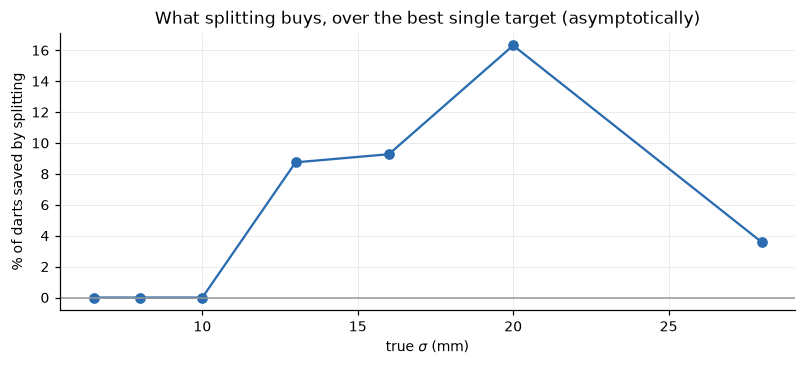

In [10]:
sub = design[['band', 'sigma_mm', 'se_best1', 'se_best2', 'se_best4', 'se_optimal']]
gain = pd.DataFrame({
    'band': sub.band, 'sigma': sub.sigma_mm,
    'split over 2': (sub.se_best1 / sub.se_best2) ** 2,
    'split over 4': (sub.se_best1 / sub.se_best4) ** 2,
    'best possible split': (sub.se_best1 / sub.se_optimal) ** 2,
})

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(gain['sigma'], 100 * (gain['best possible split'] - 1), 'o-', color='#2b6cb0')
ax.axhline(0, color='#999', lw=1)
ax.set_xlabel(r'true $\sigma$ (mm)')
ax.set_ylabel('% of darts saved by splitting')
ax.set_title('What splitting buys, over the best single target (asymptotically)')
fig.tight_layout()
gain.round(3)

### The asymptotic answer: yes, but barely

The convexity argument was right in direction and badly misleading about magnitude.

For the four tightest bands the "mixture" turns out to be a **single point**: the optimal
design has support size 1 and the equivalence certificate is exactly 1.000000. That is not
a search that failed to find a better mixture, it is a proof that none exists. For an elite,
pro, county or super league player, 200 darts at the bull genuinely beats any split of those
darts, and
100+100 is strictly *worse*.

From super league downwards the optimum is a genuine mixture spread around the board, and
splitting helps -- but only by 9 to 16% of the variance, and four targets with the darts
divided equally capture essentially all of it. Set that against the factor of 3 to 5.5
available from simply choosing a better single target, and the asymptotic ranking is clear:
**which target dominates; how many barely matters.**

That conclusion turns out to be wrong at any session length a human would actually throw.

## What happens at 100 darts

Everything above is asymptotic. A real session is a few hundred darts, $\hat\sigma$ is biased
at that size, and $\sigma$ is bounded below by zero -- so the Fisher calculation is a
prediction, not a guarantee. `scripts/design_simulation_study.py` simulates whole sessions
under each design, fits every one with the same EM estimator, and reports what actually
happens.

In [11]:
sim = pd.read_csv(os.path.join(RESULTS, 'design', 'simulation_league.csv'))
# Monte Carlo error on an RMSE estimated from n_ok replicates, so the table can
# be read without mistaking noise for a result.
sim['rmse_mc_se'] = sim.rmse / np.sqrt(2 * sim.n_ok)
order = [d for d in ['T20', 'D20', 'bull', 'best 1', 'best 2', 'best 3', 'best 4', 'best 6']
         if d in set(sim.design)]
piv = sim[sim.n == 100].set_index('design').reindex(order)[
    ['k', 'bias_pct', 'sd', 'rmse', 'rmse_mc_se', 'fisher_se']]
piv['rmse / fisher'] = piv.rmse / piv.fisher_se
print(f"true sigma = {sim.sigma_true.iloc[0]} mm, "
      f"{sim[sim.n==100].n_ok.iloc[0]} replicates of a 100-dart session")
piv.round(3)

true sigma = 16.0 mm, 250 replicates of a 100-dart session


,k,bias_pct,sd,rmse,rmse_mc_se,fisher_se,rmse / fisher
design,,,,,,,
T20,1,-7.128,1.797,2.125,0.095,1.919,1.108
D20,1,1.206,1.902,1.908,0.085,1.733,1.101
bull,1,0.652,1.338,1.340,0.060,1.285,1.043
best 1,1,-2.076,1.661,1.690,0.076,1.082,1.562
best 2,2,-0.952,1.050,1.058,0.047,1.039,1.019
best 3,3,-1.459,1.110,1.132,0.051,1.036,1.093
best 4,4,-1.368,1.134,1.153,0.052,1.035,1.113
best 6,6,-1.019,1.122,1.132,0.051,1.035,1.093


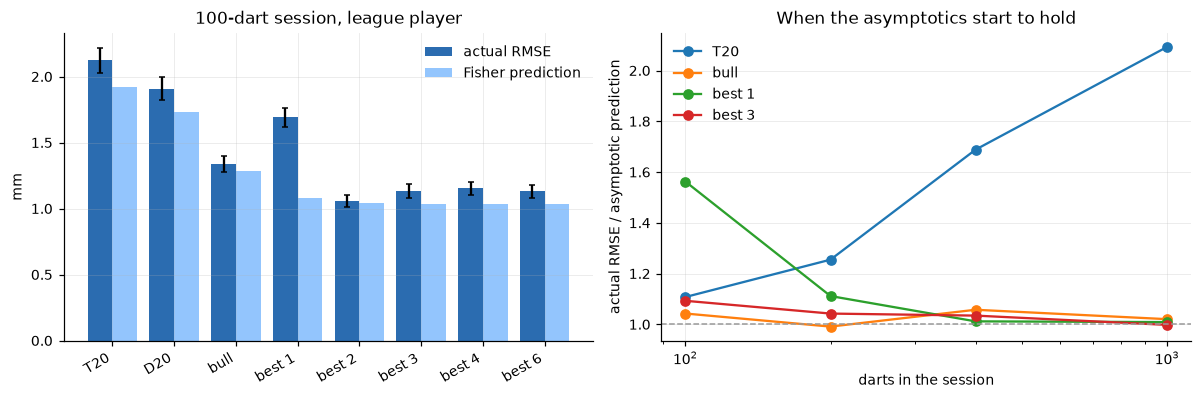

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
d100 = sim[sim.n == 100].set_index('design').reindex(order)
x = np.arange(len(d100))
axes[0].bar(x - 0.2, d100.rmse, 0.4, yerr=d100.rmse_mc_se, capsize=2,
            label='actual RMSE', color='#2b6cb0')
axes[0].bar(x + 0.2, d100.fisher_se, 0.4, label='Fisher prediction', color='#93c5fd')
axes[0].set_xticks(x); axes[0].set_xticklabels(d100.index, rotation=30, ha='right')
axes[0].set_ylabel('mm'); axes[0].set_title('100-dart session, league player')
axes[0].legend()

for name in ['T20', 'bull', 'best 1', 'best 3']:
    g = sim[sim.design == name].sort_values('n')
    if len(g):
        axes[1].plot(g.n, g.rmse / g.fisher_se, 'o-', label=name)
axes[1].axhline(1.0, color='#999', ls='--', lw=1)
axes[1].set_xscale('log')
axes[1].set_xlabel('darts in the session')
axes[1].set_ylabel('actual RMSE / asymptotic prediction')
axes[1].set_title('When the asymptotics start to hold'); axes[1].legend()
fig.tight_layout()

In [13]:
# every session length, so the finite-sample effects can be separated from noise
full = sim.pivot_table(index='design', columns='n', values='rmse').reindex(order)
mc = sim.pivot_table(index='design', columns='n', values='rmse_mc_se').reindex(order)
print('RMSE of sigma-hat (mm), with Monte Carlo error in brackets')
pd.DataFrame({c: [f'{x:.3f} ({y:.3f})' for x, y in zip(full[c], mc[c])]
              for c in full.columns}, index=full.index)

RMSE of sigma-hat (mm), with Monte Carlo error in brackets


,100,200,400,1000
design,,,,
T20,2.125 (0.095),1.703 (0.076),1.619 (0.072),1.270 (0.057)
D20,1.908 (0.085),1.214 (0.054),0.767 (0.034),0.484 (0.022)
bull,1.340 (0.060),0.900 (0.040),0.679 (0.030),0.415 (0.019)
best 1,1.690 (0.076),0.850 (0.038),0.547 (0.024),0.345 (0.015)
best 2,1.058 (0.047),0.753 (0.034),0.505 (0.023),0.312 (0.014)
best 3,1.132 (0.051),0.764 (0.034),0.536 (0.024),0.327 (0.015)
best 4,1.153 (0.052),0.748 (0.033),0.507 (0.023),0.302 (0.014)
best 6,1.132 (0.051),0.788 (0.035),0.550 (0.025),0.350 (0.016)


### At a short session, splitting is worth much more than the theory said

The asymptotics arrive at very different speeds for different designs, and the ratio
column above is the thing to read.

At 100 darts the best *single* target misses its own asymptotic bound by a wide margin,
while the split designs sit almost exactly on theirs -- so splitting buys far more than the
9% the Fisher calculation promised. That advantage then **fades as the session lengthens**:
by a few hundred darts the single target has largely caught up with its bound, and by a
thousand the split and unsplit designs are separated by little more than Monte Carlo noise,
exactly as the asymptotic analysis said they should be.

So the finite-sample case for splitting is specifically a case about *short* sessions --
which is to say, the sessions anybody will actually throw.

Read the ratio column as a diagnostic of *whether the asymptotics have arrived*, not of
whether a design is any good: the bull sits almost exactly on its bound while the best
single target misses its own by 56%, and the bull is the worse design of the two.

T20 is the design that never catches up. Its ratio moves the *wrong* way with session
length -- 1.11 at a hundred darts and 2.1 at a thousand -- so both its bias and its spread
still exceed the asymptotic prediction after a thousand throws. A flat likelihood is not merely imprecise; it converges to its
imprecision slowly, and keeps a bias that does not shrink at the rate the variance does.

The obvious explanation for the single-target shortfall would be that the aim point is an
expensive nuisance parameter -- but that is checkable, and it is false. Comparing the
variance of $\hat\sigma$ with $b$ unknown against $b$ known, the cost at the best single
target is $1.07\times$: nothing. (Only T20 carries a real nuisance cost, $1.37\times$.)

The real reason is a finite-sample one, and it lives entirely in the **lower tail**.

In [14]:
why = pd.read_csv(os.path.join(RESULTS, 'design', 'why_splitting.csv'))
sig_true = why.sigma_true.iloc[0]
summary = []
for name, g in why.groupby('design'):
    s, berr = g.sigma_hat.values, g.aim_error_mm.values
    lo = s < np.percentile(s, 25)
    q = np.percentile(s, [1, 5, 25, 50, 75, 95])
    summary.append({
        'design': name, 'k': int(g.k.iloc[0]),
        'rmse': np.sqrt(((s - sig_true) ** 2).mean()),
        '1st pct': q[0], '5th pct': q[1], 'median': q[3], '95th pct': q[5],
        'corr(sigma, aim error)': np.corrcoef(s, berr)[0, 1],
        'aim err | low sigma': berr[lo].mean(),
        'aim err | rest': berr[~lo].mean()})
pd.DataFrame(summary).set_index('design').round(3)

,k,rmse,1st pct,5th pct,median,95th pct,"corr(sigma, aim error)",aim err | low sigma,aim err | rest
design,,,,,,,,,
best 1,1,1.442,10.326,13.718,15.859,17.695,-0.478,4.984,3.356
best 2,2,1.168,13.349,13.970,15.752,17.498,-0.170,3.322,2.963
best 3,3,1.108,13.554,14.004,15.851,17.553,-0.047,3.174,3.074


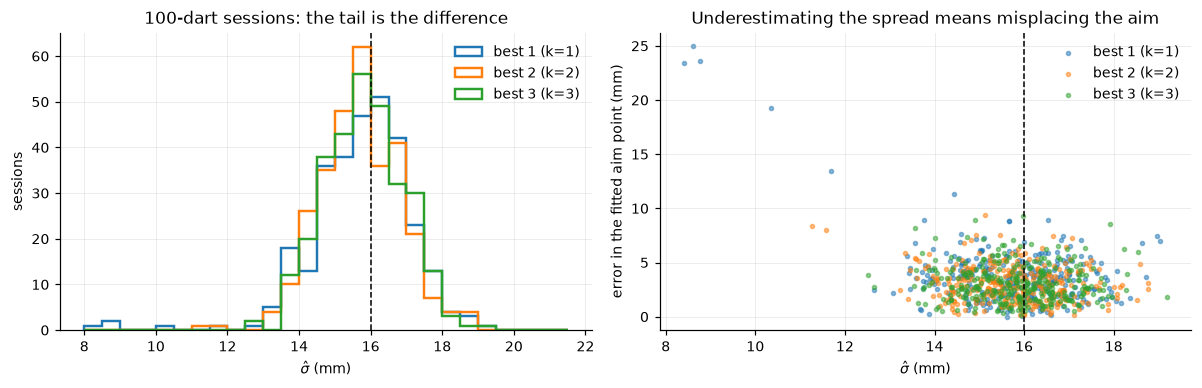

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, g in why.groupby('design'):
    axes[0].hist(g.sigma_hat, bins=np.arange(8, 22, 0.5), histtype='step', lw=1.6,
                 label=f"{name} (k={int(g.k.iloc[0])})")
axes[0].axvline(sig_true, color='k', ls='--', lw=1)
axes[0].set_xlabel(r'$\hat\sigma$ (mm)'); axes[0].set_ylabel('sessions')
axes[0].set_title('100-dart sessions: the tail is the difference'); axes[0].legend()

for name, g in why.groupby('design'):
    axes[1].scatter(g.sigma_hat, g.aim_error_mm, s=7, alpha=0.5,
                    label=f"{name} (k={int(g.k.iloc[0])})")
axes[1].axvline(sig_true, color='k', ls='--', lw=1)
axes[1].set_xlabel(r'$\hat\sigma$ (mm)'); axes[1].set_ylabel('error in the fitted aim point (mm)')
axes[1].set_title('Underestimating the spread means misplacing the aim')
axes[1].legend()
fig.tight_layout()

From a single target, an unluckily tight group of darts is explained equally well by two
different stories: *a tight thrower aiming where we thought*, and *an ordinary thrower
aiming somewhere else*. The likelihood cannot separate them, so the estimate occasionally
collapses to a much too small $\sigma$ paired with a badly displaced aim point. The scatter
plot shows exactly this -- for one target the two errors are strongly correlated.

Darts at a second and third target destroy the trade-off, because **one displaced aim point
cannot explain three different score histograms at once**. The correlation collapses and
the lower tail disappears.

This is invisible to the Fisher calculation, which describes only the curvature of the
likelihood at its peak; the trade-off is a global feature of the likelihood surface, not a
local one. As the session lengthens the tight-group-plus-displaced-aim story becomes
harder to sustain on its own, which is why the effect fades and the asymptotics take over.

So at a hundred-dart session, splitting is not a 9% refinement -- it is insurance against
occasionally getting a badly wrong answer. At a thousand darts you do not need the
insurance.

### A side effect: the good targets are also the fast ones to fit

The same flatness that makes an uninformative target imprecise also makes the EM crawl.
This is not a separate phenomenon -- a likelihood with little curvature is both hard to
estimate from and slow to climb -- but it is a useful practical tell, and it means the
better designs cost less compute as well as fewer darts.

In [16]:
from darts.fitting import fit_multi_target, simulate_session

d_league = np.load(os.path.join(RESULTS, 'design', 'design_league.npz'), allow_pickle=True)
probe = {'T20': [np.array([0.0, 103.0])], 'bull': [np.zeros(2)],
         'best 1': [np.asarray(d_league['design_1_mm'][0])],
         'best 3': [np.asarray(p) for p in d_league['design_3_mm']]}

rows = []
for name, targets in probe.items():
    k = len(targets)
    steps, secs = [], []
    for seed in range(12):
        sess = simulate_session(targets, [200 // k] * k, np.array([2.0, -3.0]),
                                SIGMA ** 2 * np.eye(2), board=BOARD, seed=seed)
        import time as _t
        t0 = _t.perf_counter()
        f = fit_multi_target(sess, board=BOARD)
        secs.append(_t.perf_counter() - t0)
        steps.append(f['n_em_steps'])
    rows.append({'design': name, 'k': k, 'mean EM steps': np.mean(steps),
                 'mean seconds': np.mean(secs)})
pd.DataFrame(rows).set_index('design').round(2)

,k,mean EM steps,mean seconds
design,,,
T20,1,78.58,1.75
bull,1,15.75,0.42
best 1,1,27.50,0.69
best 3,3,22.50,1.72


## If you do not know the player's ability yet

There is still a circularity. The best target depends on the $\sigma$ you are trying to
measure. So: how much does guessing wrong cost, and is there one routine that works for
everybody?

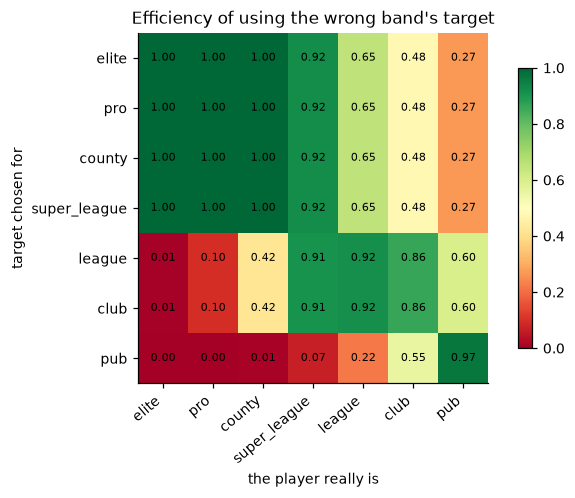

In [17]:
cross = pd.read_csv(os.path.join(RESULTS, 'manifest_design_cross.csv'), index_col=0)
fig, ax = plt.subplots(figsize=(6.4, 4.6))
im = ax.imshow(cross.values, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels(cross.columns, rotation=40, ha='right')
ax.set_yticks(range(len(cross.index))); ax.set_yticklabels(cross.index)
ax.set_xlabel('the player really is'); ax.set_ylabel('target chosen for')
ax.set_title("Efficiency of using the wrong band's target"); ax.grid(False)
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        ax.text(j, i, f'{cross.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

In [18]:
robust = pd.read_csv(os.path.join(RESULTS, 'manifest_design_robust.csv'))
robust.round(3)

,k,worst_efficiency,targets,radii_mm,eff_elite,eff_pro,eff_county,eff_super_league,eff_league,eff_club,eff_pub
0,1,0.275,25,11,0.316,0.297,0.471,0.638,0.521,0.421,0.275
1,2,0.606,BULL + T9,0;106,0.643,0.708,0.760,0.757,0.606,0.612,0.623
2,3,0.634,BULL + T12 + 16,0;104;83,0.640,0.710,0.753,0.757,0.634,0.652,0.657
3,4,0.628,BULL + BULL + 3 + T11,0;4;116;106,0.636,0.658,0.701,0.736,0.629,0.653,0.628


### This is where splitting really earns its keep

The single-ability analysis made splitting look marginal. That analysis assumed you already
knew $\sigma$ -- and you do not, which is the entire point of the exercise.

Once the target must be chosen before the answer is known, a single target is exposed. The
best single compromise target manages only **28%** worst-case efficiency across the ability
range; three targets reach **63%**. Splitting more than doubles the worst case.

(The four-target row is marginally *worse* than three. That is real and not a search
failure: with four equal allocations you cannot express the thirds that the best three-target
design uses, and the minimax search's best four-point answer instead doubles up on the bull.)

So the honest answer to "is 100 + 100 better than 200 at one point?" depends entirely on
what you are allowed to assume:

* **asymptotically, knowing the player's standard** -- barely, and for a tight player, not
  at all: a single point is provably optimal;
* **at a short session** -- yes, clearly, because it removes the tail risk of a badly wrong
  answer. That advantage shrinks as the session lengthens;
* **not knowing the player's standard** -- yes, decisively, and this is the case that
  actually applies.

## Better still: two stages

Hedging is not the only option. Spend a first batch of darts on the robust design, get a
rough $\sigma$, then spend the rest at the target that is best for *that* player, read off
the lookup table.

The simulation below includes the fact that stage two's target is chosen from a *noisy*
stage-one estimate. The **oracle** row is what you would get by throwing every dart at the
single target best for the player's true $\sigma$ -- which nobody can do, since it requires
knowing the answer in advance.

One thing to keep straight when reading it: the oracle is the best *single-target* design,
not the best design of any kind. A two-stage session automatically ends up spread across
several targets, so by the short-session argument above it can legitimately match or even
edge past the oracle. That is not a paradox and not an error; it is the splitting benefit
arriving by the back door.

In [19]:
two = pd.read_csv(os.path.join(RESULTS, 'design', 'two_stage.csv'))
order2 = ['T20', 'bull', 'robust (all darts)', 'stage 1 only', 'two stage', 'oracle']
piv2 = two.pivot(index='method', columns='band', values='rmse').reindex(order2)
piv2 = piv2[[b for b in ['county', 'league', 'pub'] if b in piv2.columns]]
print(f'{int(two.n.iloc[0])} darts in total')
piv2.round(3)

200 darts in total


band,county,league,pub
method,,,
T20,0.947,1.605,1.484
bull,0.432,0.924,2.103
robust (all darts),0.516,0.870,1.492
stage 1 only,1.355,1.964,2.974
two stage,0.448,0.801,1.296
oracle,0.457,0.971,1.660


band,county,league,pub
method,,,
T20,2.07,1.65,0.89
bull,0.94,0.95,1.27
robust (all darts),1.13,0.90,0.90
stage 1 only,2.96,2.02,1.79
two stage,0.98,0.83,0.78
oracle,1.00,1.00,1.00


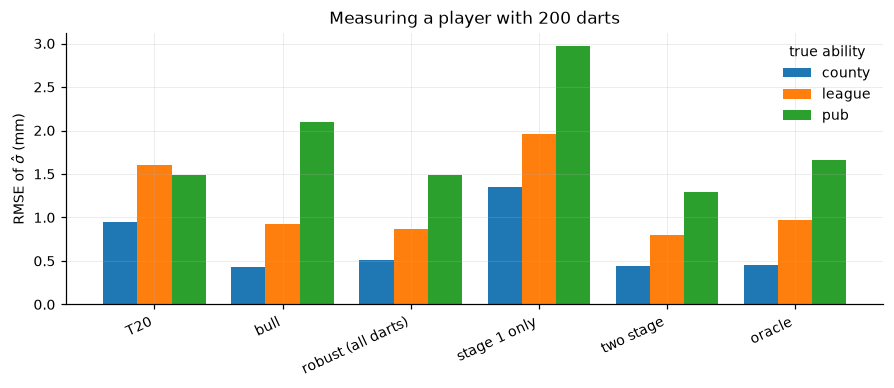

In [20]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
bands_here = list(piv2.columns)
x = np.arange(len(order2))
w = 0.8 / len(bands_here)
for i, b in enumerate(bands_here):
    ax.bar(x + (i - (len(bands_here) - 1) / 2) * w, piv2[b], w, label=b)
ax.set_xticks(x); ax.set_xticklabels(order2, rotation=25, ha='right')
ax.set_ylabel(r'RMSE of $\hat\sigma$ (mm)')
ax.set_title(f'Measuring a player with {int(two.n.iloc[0])} darts')
ax.legend(title='true ability')
fig.tight_layout()

(piv2 / piv2.loc['oracle']).round(2)

## What to actually do

**Do not measure a player at T20.** It is where they will want to throw and it is among the
worst targets on the board: a factor of 3.1 in variance for a league player and 5.5 for an
elite one. It is also the one design whose error does not settle down -- at a thousand
darts it is still well above its own asymptotic bound, and it needs about five times as
many EM iterations to fit, because a flat likelihood is slow to climb as well as imprecise.

**If you already know roughly how good they are**, read the target off
`results/manifest_best_target.csv`:

| their standard | throw at | why |
|---|---|---|
| $\sigma \lesssim 13$mm (super league and better) | the **bull** | its two rings, at 6.35 and 15.9mm, sit at the scale of their scatter |
| $\sigma \approx 14$–22mm (league to club) | the **big single, ~136mm out** | segment boundaries plus the double ring, both at the right scale |
| $\sigma \gtrsim 22$mm (pub) | the **treble ring, ~105mm out** | the point from which the widest variety of scores is reachable |

The *number* barely matters -- every segment at the best radius is within a few percent --
so let them throw at whichever one they find comfortable.

**If you do not know how good they are, which is the normal case**, do it in two stages:
spend the first quarter of the darts on the bull plus two trebles, fit a rough $\sigma$,
then spend the rest at the target that the table points to. In the simulations it beat the
best-single-target oracle at all three abilities, and beat every fixed choice except the bull
for the county player -- who is tight enough that the bull is simply the right answer.

**And on the original question -- is 100 + 100 better than 200 at one spot?**

The convexity argument says a mixture should win, and it does, but the size of the effect
depends entirely on what you are allowed to assume:

* **Knowing $\sigma$, asymptotically:** barely. For a tight player it is provably *worse* --
  the optimal design has support size 1, certified at 1.000000, so 200 at the bull beats
  any split of them. For a loose player splitting is worth 9–16% of the variance.
* **At a short session:** yes, clearly. At 100 darts, splitting three ways is worth a
  factor of 2.2 in variance -- far more than the 9% on the tin. That is because from a
  single target an unluckily tight group is indistinguishable from a displaced aim point,
  and the fit occasionally collapses onto a much too small $\sigma$. Adding targets destroys
  the trade-off: the correlation between the fitted spread and the aim-point error falls
  from $-0.48$ to $-0.05$. The advantage fades as the session lengthens and is gone by a
  thousand darts, exactly as the asymptotics say.
* **Not knowing $\sigma$:** decisively. One compromise target manages 28% worst-case
  efficiency across the ability range; three reach 63%.

So the honest summary is that **choosing the target is worth far more than splitting it**,
by an order of magnitude or two -- but splitting is what protects you when you cannot choose
well, which is precisely the situation you are in before the measurement.

### What this says about notebook 07

Notebook 07 concluded that a couple of hundred darts only places a player in a band, that
the aim point is weakly identified, and that seeing "only 6–9 distinct scores" was *the
fundamental limit here*. Every one of those fits was done at T20.

The first two conclusions survive -- they are about the identifiability of an 8mm bed and
they are real. The third does not: the narrow range of observed scores is a property of the
target, not of the method. Move to the right target and the same 200 darts do considerably
better; the limit was a choice nobody had noticed making.

### Loose ends

* Everything here assumes the player aims where they are told, with a bias that is the same
  at every target. `fit_multi_target(..., shared_bias=False)` relaxes the second half at a
  cost of $2k$ parameters, but a bias that drifts *during* a session is not modelled at all.
* The designs are optimal for estimating a single isotropic $\sigma$. A player who wants
  their full covariance -- the tilted, vertically-stretched throw of notebook 07 -- wants a
  D-optimal design instead, which `d_criterion` supports but which has not been searched.
* All of it is simulated. The obvious next step is to take a real player, run the two-stage
  routine, and find out whether a Gaussian with a constant bias describes them at all.

---

# Appendix: the checks behind the numbers

Four claims are made in passing above. Each is cheap to verify and each would change a
conclusion if it were false, so they are computed here rather than asserted.

## 1. Is the aim point an expensive nuisance parameter?

The natural explanation for the best single target missing its asymptotic bound at 100
darts would be that it spends its information locating $b$ rather than measuring $\sigma$.
Comparing $\mathrm{Var}(\hat\sigma)$ with $b$ unknown against $b$ known settles it.

In [21]:
c3 = np.array([1 / (4 * SIGMA), 0.0, 1 / (4 * SIGMA)])   # d sigma / d(S_xx, S_xy, S_yy)
probe_pts = {'bull': polar(0, 0), 'T20': polar(103, 0), 'D20': polar(166, 0),
             'best single': tuple(cand[i1])}
rows = []
for name, p in probe_pts.items():
    I = maps['info'][p[0], p[1]]
    v_unknown = float(c_vec @ np.linalg.solve(I, c_vec))
    v_known = float(c3 @ np.linalg.solve(I[2:, 2:], c3))
    rows.append({'target': name, 'Var, b unknown': v_unknown,
                 'Var, b known': v_known, 'cost of the nuisance': v_unknown / v_known})
best3_idx, _ = greedy_design(I_pts, c_vec, 3)
M3 = design_information(I_pts[best3_idx], np.ones(3))
rows.append({'target': 'best 3', 'Var, b unknown': float(c_vec @ np.linalg.solve(M3, c_vec)),
             'Var, b known': float(c3 @ np.linalg.solve(M3[2:, 2:], c3)),
             'cost of the nuisance': float(c_vec @ np.linalg.solve(M3, c_vec))
                                     / float(c3 @ np.linalg.solve(M3[2:, 2:], c3))})
pd.DataFrame(rows).set_index('target').round(3)

,"Var, b unknown","Var, b known",cost of the nuisance
target,,,
bull,165.046,165.046,1.000
T20,368.065,269.342,1.367
D20,300.459,300.024,1.001
best single,117.050,109.905,1.065
best 3,107.368,107.228,1.001


So the answer is **no**: at the best single target the aim point costs 7% of the variance,
which is nothing. Only T20 carries a real nuisance cost. The finite-sample shortfall
measured earlier therefore has to be a global feature of the likelihood, not a local one --
which is what the tail diagnostic showed.

## 2. Does any of it depend on the pixel grid?

The design criterion is computed on a discretised board. Notebook 02 validated the 512-pixel
board against exact-geometry Monte Carlo; what matters here is whether the *design* answers
move with resolution. The last two columns are the ones to watch: an 8 mm bed is only 4.5
pixels across at 256 and 2.3 at 128, so a target defined by a bed is where a coarse board
should fail first.

In [22]:
rows = []
for sigma_r in [6.5, 16.0, 28.0]:
    for px_r in [128, 256, 512]:
        b_r, _ = generate_dartboard(px_r)
        m_r = information_maps(px_r, sigma_r, board=b_r)
        c_r = sigma_gradient(sigma_r)
        cand_r = candidate_targets(px_r, point_stride=max(1, px_r // 128))
        I_r = information_at_points(m_r, cand_r)
        j, v_r, _ = best_single_target(I_r, c_r)
        opt_r = optimal_design(I_r, c_r)
        centre_r, mm_r = px_r // 2, mm_per_pixel(px_r)
        # T20 as well as the optimum: a bed-centred target is where the
        # discretisation of an 8mm bed can actually be felt
        t20 = (int(round(centre_r + 103 / mm_r)), centre_r)
        se_t20 = np.sqrt(c_criterion(m_r['info'][t20[0], t20[1]], c_r) / N_REF)
        rows.append({
            'sigma': sigma_r, 'pixels': px_r,
            'best target': aim_description(cand_r[j], px_r),
            'radius (mm)': np.hypot((cand_r[j][0] - centre_r) * mm_r,
                                    (cand_r[j][1] - centre_r) * mm_r),
            'SE best single': np.sqrt(v_r / N_REF),
            'SE optimal': np.sqrt(opt_r['value'] / N_REF),
            'SE at T20': se_t20,
            'bed width (px)': 8.0 / mm_r})
res = pd.DataFrame(rows).set_index(['sigma', 'pixels'])
res.round(3)

best target  radius (mm)  SE best single  SE optimal  SE at T20  \
sigma pixels                                                                   
6.5   128           BULL        0.000           0.277       0.277      3.851   
      256           BULL        0.000           0.273       0.273      3.779   
      512           BULL        0.000           0.272       0.272      0.636   
16.0  128             20      133.891           0.757       0.725      1.742   
      256             20      133.891           0.766       0.733      1.638   
      512              9      136.007           0.765       0.732      1.357   
28.0  128             T5      105.996           1.241       1.220      1.270   
      256             T5      105.996           1.243       1.222      1.278   
      512             T5      105.996           1.244       1.222      1.265   

              bed width (px)  
sigma pixels                  
6.5   128              2.271  
      256              4.541  
      512              9.082  
16.0  128              2.271  
      256              4.541  
      512              9.082  
28.0  128              2.271  
      256              4.541  
      512              9.082

**The optimum is robust and a bad target is not**, and the distinction matters more than it
looks.

The best target's standard error agrees to better than 1% across 128, 256 and 512 pixels,
and its radius is stable. Which particular segment wins at $\sigma = 16$ is not stable, but
that is the near-tie measured earlier -- every number at that radius is within about 2% --
so the argmax is free to wander, and the recommendation is a radius rather than a bed for
exactly this reason.

**T20 is a different story.** For an elite player its standard error reads 3.78 mm at 256
pixels and 0.64 mm at 512 -- a factor of six, from nothing but the board getting finer. A
6.5 mm group sitting on an 8 mm bed is exactly the configuration a 4.5-pixel bed cannot
represent, so the coarse board loses most of the treble's structure and reports a target far
less informative than it is. At $\sigma = 28$ mm, where the group is much larger than the
bed, all three resolutions agree to 1%.

The lesson generalises past this notebook: a design *search* is safe on a coarse board
because the optimum is somewhere the board is smooth, while a *comparison against a
particular bad target* is not, because bad targets are bad precisely where the board has
fine structure.

## 3. Does dropping the rare scores matter?

`information_maps` skips scores whose probability at a given target is below a floor, to
keep $1/p_s$ finite. Rare scores are also the ones carrying the fattest tails, so it is
worth checking that the floor is not quietly throwing away signal.

In [23]:
rows = []
for sigma_f in [6.5, 16.0]:
    c_f = sigma_gradient(sigma_f)
    row = {'sigma': sigma_f}
    for fl in [1e-10, 1e-12, 1e-14, 1e-16, 0.0]:
        m_f = information_maps(PX, sigma_f, board=BOARD, floor=fl)
        row[f'floor {fl:g}'] = float(np.sqrt(
            c_criterion(m_f['info'][CENTRE, CENTRE], c_f) / N_REF))
    rows.append(row)
floor_tbl = pd.DataFrame(rows).set_index('sigma')
print('SE of sigma-hat at the bull, by rare-score floor:')
floor_tbl

SE of sigma-hat at the bull, by rare-score floor:


,floor 1e-10,floor 1e-12,floor 1e-14,floor 1e-16,floor 0
sigma,,,,,
6.5,0.272332,0.272332,0.272332,0.272332,0.272332
16.0,0.908423,0.908423,0.908423,0.908423,0.908423


Identical to every digit shown. A score with probability $p$ contributes $g^2/p$ to the
information, and for these tails $g$ falls with $p$, so the contribution vanishes faster
than the floor does. The floor is doing nothing but keeping the arithmetic finite.

## 4. Is the isotropic parameterisation consistent with the full one?

Most of this project describes a player by a single `sigma`, but the design code carries the
full five-parameter $(b, \Sigma)$. The isotropic model should be exactly the full one
restricted to $\Sigma = \sigma^2 I$, which means its information must be $J^\top I J$ for the
Jacobian of that embedding. This pins down the unit conversions and the chain rule in the
derivative code far more tightly than comparing variances would.

In [24]:
sigma_i = 15.0
pts_i = candidate_targets(PX_V, point_stride=8)
full_i = information_at_points(information_maps(PX_V, sigma_i, board=board_v), pts_i)
iso_i = information_at_points(
    information_maps(PX_V, sigma_i, params='isotropic', board=board_v), pts_i)

J = np.zeros((5, 3))
J[0, 0] = J[1, 1] = 1.0
J[2, 2] = J[4, 2] = 2 * sigma_i          # d Sigma_xx / d sigma = d Sigma_yy / d sigma
err = np.abs(iso_i - np.einsum('ai,pab,bj->pij', J, full_i, J)).max()

v_full = c_criterion(full_i, sigma_gradient(sigma_i))
v_iso = c_criterion(iso_i, sigma_gradient(sigma_i, params='isotropic'))
print(f'max |I_iso - J^T I_full J|            : {err:.2e}')
print(f'scale of I_iso                        : {np.abs(iso_i).max():.2e}')
print(f'worst case of Var_iso > Var_full      : {(v_iso / v_full).max() - 1:.2e} (relative)')
print('\nEstimating three parameters instead of five cannot make sigma less precise,')
print('and the two coincide exactly at the bull, where the constraint does not bind.')

max |I_iso - J^T I_full J|            : 4.25e-17
scale of I_iso                        : 1.08e-02
worst case of Var_iso > Var_full      : 1.61e-09 (relative)

Estimating three parameters instead of five cannot make sigma less precise,
and the two coincide exactly at the bull, where the constraint does not bind.


## 5. Does the multi-target fit reduce to the single-target one?

`fit_multi_target` is the estimator every design in this notebook was scored with, including
the single-target ones. If it did not agree with notebook 07's `fit_from_scores` at $k = 1$,
the comparison between designs would be confounded by a change of estimator.

In [25]:
from darts.fitting import fit_from_scores, simulate_scores

board_r, _ = generate_dartboard(PX)
t_r = np.array([0.0, 103.0])
scores_r = simulate_scores(600, t_r + np.array([3.0, -4.0]), 15.0 ** 2 * np.eye(2),
                           board=board_r, seed=1)
a = fit_from_scores(scores_r, board=board_r, mu_init=t_r, tol=1e-12, max_iter=2000)
b = fit_multi_target([(t_r, scores_r)], board=board_r, tol=1e-12, max_iter=2000)
print(f'single-target fit : mu {a["mu"].round(6)}  sigma {a["sigma_mm"]:.6f}')
print(f'multi-target, k=1 : mu {(t_r + b["b"]).round(6)}  sigma {b["sigma_mm"]:.6f}')
print(f'difference in log-likelihood: {abs(a["log_likelihood"] - b["log_likelihood"]):.2e}')
print('\n(They agree only when started from the same point: EM is slow enough here that')
print(' the old default tolerance of 1e-8 stopped with sigma still moving.)')

single-target fit : mu [ 2.153524 96.548825]  sigma 14.018223
multi-target, k=1 : mu [ 2.153516 96.548797]  sigma 14.018214
difference in log-likelihood: 3.08e-10

(They agree only when started from the same point: EM is slow enough here that
 the old default tolerance of 1e-8 stopped with sigma still moving.)
